# Time-Stretch Dispersive Fourier Transform (TS-DFT)

**Jalali Lab technique** (UCLA) enabling real-time spectroscopy at GHz rates.

Core idea: a short pulse propagates through a dispersive fiber (GVD).
In the far-field limit, the **output intensity in time = input spectrum in frequency**:

```
I_out(t) ~ |E(omega)|^2    at   omega = t / (beta2 * L)
```

This notebook covers:
1. Five key equations (sp.init_printing)
2. C-to-kwargs abstraction pattern
3. Gaussian pulse GVD propagation
4. Far-field approximation vs exact (correlation)
5. Causality: all-pass filter + Kramers-Kronig
6. Thermal noise floor (Bose-Einstein at telecom)
7. RogueGuard connection


In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from dgs.dispersive_fourier import (
    gaussian_pulse, gvd_propagate, dispersive_fourier_transform,
    gvd_transfer_function, kramers_kronig_n, verify_causality_gvd,
    partition_function_harmonic, equipartition_check, tsdft_sympy_5,
    C_LIGHT, HBAR, K_BOLTZ,
)
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
print("Loaded dgs.dispersive_fourier")


Loaded dgs.dispersive_fourier


## S1 Five Key Equations

In [2]:
sp.init_printing(use_latex=False)
eqs = tsdft_sympy_5()
print("=" * 60)
print("TIME-STRETCH DISPERSIVE FOURIER TRANSFORM")
print("=" * 60)
for name, eq in eqs.items():
    print(f"\n  [{name}]")
    print(f"    {eq}")


TIME-STRETCH DISPERSIVE FOURIER TRANSFORM

  [GVD_transfer_H]
    Eq(H, exp(I*L*beta_2*omega**2/2))

  [TS-DFT_far_field]
    Eq(I_out(t), Abs(E(t/(L*beta_2)))**2)

  [group_delay_tau]
    Eq(tau, L*beta_2*omega)

  [dispersion_length_L_D]
    Eq(L_D, T_0**2/Abs(beta_2))

  [Bose-Einstein_n_BE]
    Eq(n_BE, 1/(exp(hbar*omega_0/(T*k_B)) - 1))


## S2 C-to-kwargs Pattern

C function signature:
```c
void gvd_propagate(complex double *E_in, int N,
                   double beta2, double L, double dt,
                   complex double *E_out);
```
Python kwargs version: named, validated, returns full diagnostic dict.


In [3]:
# C-to-kwargs: positional int/pointer C args -> named, validated Python kwargs
N = 2048; dt = 1e-12; T0 = 2e-12
beta2 = -20e-27   # SMF-28 at 1550nm: -20 ps^2/km
L = 5000.0        # 5 km fiber

pulse = gaussian_pulse(N, T0, dt)
res = gvd_propagate(pulse, beta2=beta2, L_m=L, dt_s=dt)

print(f"L_D  = {res['L_D_m']:.1f} m")
print(f"M    = {res['stretch_factor']:.0f}x  (far-field: {res['far_field_ok']})")
print(f"GVD  = {beta2*1e27:.1f} ps^2/km  (SMF-28: -20)")
print(f"Group delay at omega=1 THz: {res['group_delay_ps'][1]:.3f} ps")


L_D  = 100.0 m
M    = 50x  (far-field: True)
GVD  = -20.0 ps^2/km  (SMF-28: -20)
Group delay at omega=1 THz: -0.307 ps


## S3 Gaussian Pulse Propagation

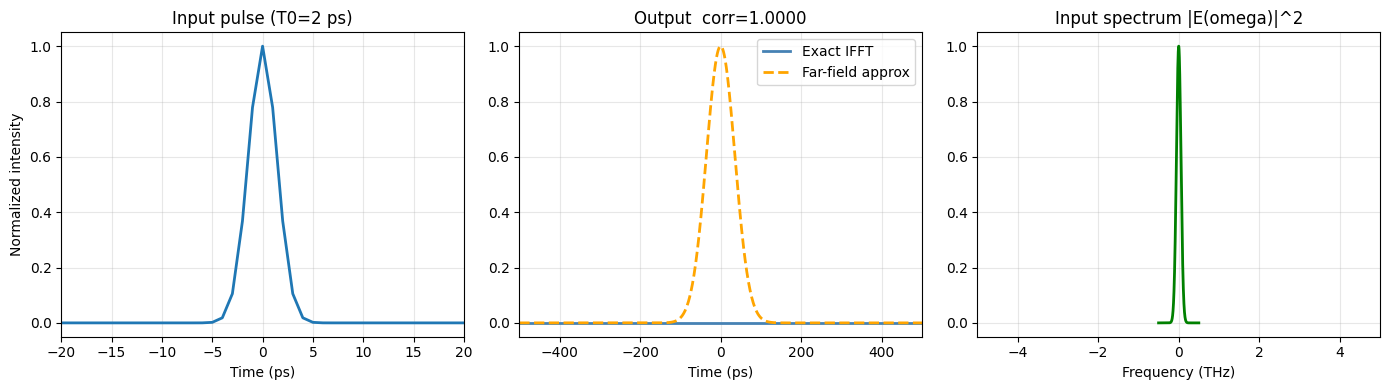

ff_correlation = 1.000000  (>0.99 means far-field ok)


In [4]:
res = dispersive_fourier_transform(pulse, beta2=beta2, L_m=L, dt_s=dt)

t_ps  = res['t_axis_s'] * 1e12
I_in  = np.abs(pulse)**2
I_out = res['I_out_shifted']
I_ff  = res['I_far_field']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t_ps, I_in / I_in.max(), lw=2)
axes[0].set_title(f"Input pulse (T0={T0*1e12:.0f} ps)")
axes[0].set_xlabel("Time (ps)"); axes[0].set_ylabel("Normalized intensity")
axes[0].set_xlim(-20, 20)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ps, I_out / I_out.max(), lw=2, label="Exact IFFT", color="steelblue")
axes[1].plot(t_ps, I_ff / I_ff.max(), lw=2, ls="--", label="Far-field approx", color="orange")
axes[1].set_title(f"After {L/1e3:.0f} km fiber  (M={res['stretch_factor']:.0f}x)")
axes[1].set_xlabel("Time (ps)")
axes[1].set_xlim(-500, 500)
axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_title(f"Output  corr={res['ff_correlation']:.4f}")

omega_THz = res['omega'] / (2*np.pi*1e12)
I_w = res['I_omega']
axes[2].plot(np.fft.fftshift(omega_THz), np.fft.fftshift(I_w / I_w.max()), lw=2, color="green")
axes[2].set_title("Input spectrum |E(omega)|^2")
axes[2].set_xlabel("Frequency (THz)"); axes[2].set_xlim(-5, 5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsdft_propagation.png", dpi=90)
plt.show()
print(f"ff_correlation = {res['ff_correlation']:.6f}  (>0.99 means far-field ok)")


## S4 Causality: All-Pass Filter + Group Delay

All-pass |H|=1: True
GVD = -20.0 ps^2/km
GVD is causal: each omega arrives at tau=beta2*L*omega. High freq (beta2>0) arrive later (normal dispersion). |H|=1 everywhere -- pure phase, no amplitude attenuation.


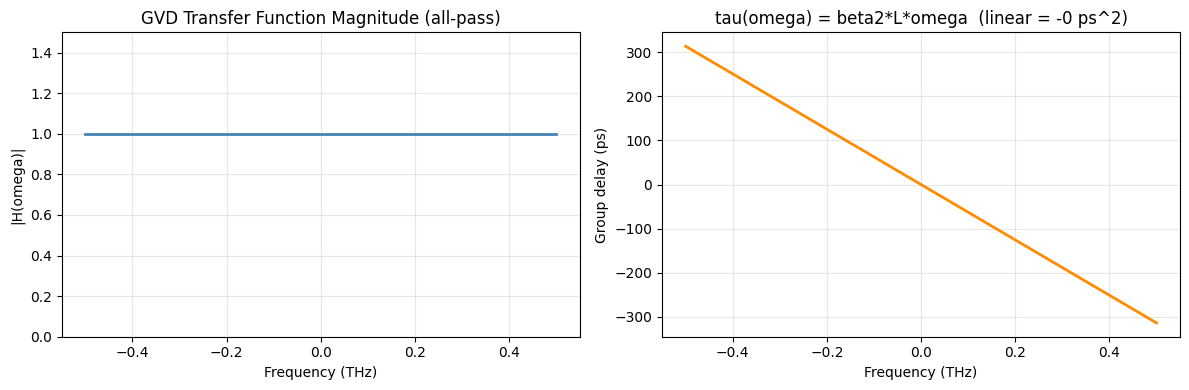

In [5]:
caus = verify_causality_gvd(beta2, L)
print(f"All-pass |H|=1: {caus['all_pass']}")
print(f"GVD = {caus['GVD_ps2_km']:.1f} ps^2/km")
print(caus['interpretation'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
omega_THz = caus['omega'] / (2*np.pi*1e12)
axes[0].plot(omega_THz, np.abs(caus['H']), lw=2, color="steelblue")
axes[0].set_ylim(0, 1.5)
axes[0].set_xlabel("Frequency (THz)"); axes[0].set_ylabel("|H(omega)|")
axes[0].set_title("GVD Transfer Function Magnitude (all-pass)")
axes[0].grid(True, alpha=0.3)

gd_ps = caus['group_delay'] * 1e12
axes[1].plot(omega_THz, gd_ps, lw=2, color="darkorange")
axes[1].set_xlabel("Frequency (THz)"); axes[1].set_ylabel("Group delay (ps)")
axes[1].set_title(f"tau(omega) = beta2*L*omega  (linear = {beta2*L*1e12:.0f} ps^2)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsdft_causality.png", dpi=90)
plt.show()


## S5 Kramers-Kronig: n(omega) from kappa(omega)

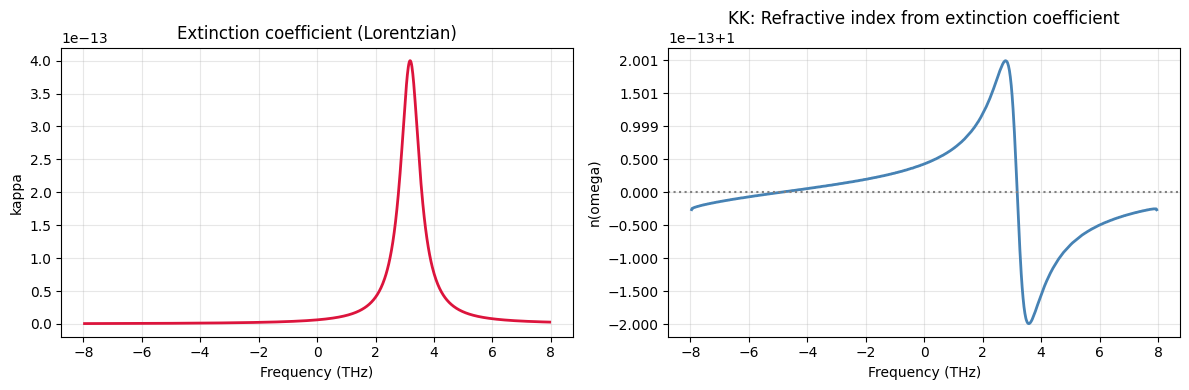

Kramers-Kronig enforces causality: n(omega) is not independent of kappa(omega).


In [6]:
omega = np.linspace(-5e13, 5e13, 1024)
# Lorentzian absorption line at omega_0
omega_0, gamma = 2e13, 5e12
kappa = (gamma/2) / ((omega - omega_0)**2 + (gamma/2)**2)
kappa = np.maximum(kappa, 0)
n_arr = kramers_kronig_n(omega, kappa)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
w_THz = omega / (2*np.pi*1e12)
axes[0].plot(w_THz, kappa, lw=2, color="crimson", label="kappa (absorption)")
axes[0].set_xlabel("Frequency (THz)"); axes[0].set_ylabel("kappa")
axes[0].set_title("Extinction coefficient (Lorentzian)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(w_THz, n_arr, lw=2, color="steelblue", label="n(omega)")
axes[1].set_xlabel("Frequency (THz)"); axes[1].set_ylabel("n(omega)")
axes[1].set_title("KK: Refractive index from extinction coefficient")
axes[1].axhline(1.0, color="gray", ls=":")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tsdft_kk.png", dpi=90)
plt.show()
print("Kramers-Kronig enforces causality: n(omega) is not independent of kappa(omega).")


## S6 Thermal Physics: Bose-Einstein at Telecom

=== Telecom 1550 nm at 300 K ===
  hbar*omega = 0.8000 eV
  kT         = 0.0259 eV
  x = hbar*omega/kT = 30.9  >> 1 (quantum)
  <n_BE>     = 3.650e-14  (shot-noise limited)
  <E>        = 0.4000 eV  (zero-point only)

=== Equipartition breakdown ===
  Classical 3DOF: 0.0776 eV
  Telecom mode:   3.9999e-01 eV  (quantum suppressed by e^31)
  Microwave 10GHz:0.0259 eV  (semi-classical, ok)


D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\dgs\dispersive_fourier.py:346: RuntimeWarning: overflow encountered in exp
  n_BE    = 1 / (np.exp(x) - 1) if x > 1e-10 else K_BOLTZ * T_K / (HBAR * omega_0)
D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\dgs\dispersive_fourier.py:351: RuntimeWarning: overflow encountered in exp
  ex      = np.exp(x)
D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\dgs\dispersive_fourier.py:352: RuntimeWarning: invalid value encountered in scalar divide
  C_v     = K_BOLTZ * x**2 * ex / (ex - 1)**2


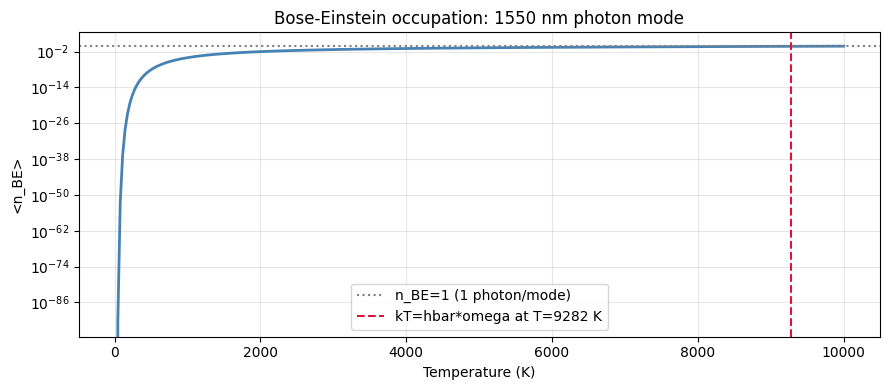

In [7]:
# Partition function for optical mode at telecom wavelength
omega_tc = 2 * np.pi * C_LIGHT / 1550e-9
pf = partition_function_harmonic(omega_tc, 300.0)
print("=== Telecom 1550 nm at 300 K ===")
print(f"  hbar*omega = {pf['hbar_omega_eV']:.4f} eV")
print(f"  kT         = {pf['kT_eV']:.4f} eV")
print(f"  x = hbar*omega/kT = {pf['x']:.1f}  >> 1 (quantum)")
print(f"  <n_BE>     = {pf['n_BE']:.3e}  (shot-noise limited)")
print(f"  <E>        = {pf['E_mean_eV']:.4f} eV  (zero-point only)")

eq_check = equipartition_check(300.0)
print()
print("=== Equipartition breakdown ===")
print(f"  Classical 3DOF: {eq_check['E_classical_eV']:.4f} eV")
print(f"  Telecom mode:   {eq_check['E_telecom_eV']:.4e} eV  (quantum suppressed by e^{pf['x']:.0f})")
print(f"  Microwave 10GHz:{eq_check['E_microwave_eV']:.4f} eV  (semi-classical, ok)")

# Temperature sweep
T_arr = np.linspace(10, 10000, 300)
n_BE_arr = [partition_function_harmonic(omega_tc, T)['n_BE'] for T in T_arr]
fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(T_arr, n_BE_arr, lw=2, color="steelblue")
ax.axhline(1.0, color="gray", ls=":", label="n_BE=1 (1 photon/mode)")
ax.axvline(HBAR*omega_tc/K_BOLTZ, color="crimson", ls="--",
           label=f"kT=hbar*omega at T={HBAR*omega_tc/K_BOLTZ:.0f} K")
ax.set_xlabel("Temperature (K)"); ax.set_ylabel("<n_BE>")
ax.set_title("Bose-Einstein occupation: 1550 nm photon mode")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("tsdft_bose_einstein.png", dpi=90)
plt.show()


## S7 RogueGuard Connection

The TS-DFT is the core sensing principle of the RogueGuard optical rogue wave monitor:

| TS-DFT concept | RogueGuard hardware |
|---|---|
| GVD fiber: H(omega) | Dispersion-compensating fiber (DCF) spool |
| Far-field: I(t)~|E(omega)|^2 | Single photodetector replaces OSA |
| Group delay tau=beta2*L*omega | Maps spectral bins to time slots |
| T0 ~ 100 fs pulses | Mode-locked laser source |
| L_D = T0^2/|beta2| | DCF length = stretch factor M target |
| n_BE << 1 at telecom | Shot-noise limited -> CNN detects rare events |
| KK causality | Physical constraint on fiber n(omega) |


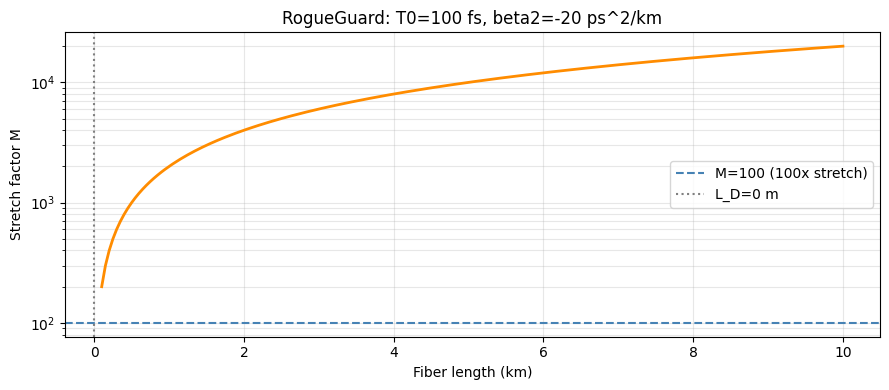

L_D = 500.00 mm  -> 1 km fiber gives M = 2000x stretch


In [8]:
# Stretch factor vs fiber length (RogueGuard design trade)
T0 = 100e-15       # 100 fs pulses
beta2 = -20e-27    # SMF-28
L_D_fs = T0**2 / abs(beta2)

L_arr = np.linspace(0.1, 10.0, 200) * 1e3   # 0.1 to 10 km
M_arr = L_arr / L_D_fs

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogy(L_arr/1e3, M_arr, lw=2, color="darkorange")
ax.axhline(100, color="steelblue", ls="--", label="M=100 (100x stretch)")
ax.axvline(L_D_fs/1e3, color="gray", ls=":", label=f"L_D={L_D_fs:.0f} m")
ax.set_xlabel("Fiber length (km)"); ax.set_ylabel("Stretch factor M")
ax.set_title(f"RogueGuard: T0={T0*1e15:.0f} fs, beta2={beta2*1e27:.0f} ps^2/km")
ax.legend(); ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("tsdft_rogueguard.png", dpi=90)
plt.show()
print(f"L_D = {L_D_fs*1e3:.2f} mm  -> 1 km fiber gives M = {1000/L_D_fs:.0f}x stretch")
